In [1]:
#Find the data files
import os 
for root,_,files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root,f))

/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_abnormal.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_normal.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv


In [2]:
#Data loading & tensor making
import pandas as pd, numpy as np, torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset,DataLoader
TRAIN_PATH="/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv"
TEST_PATH="/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv"

train=pd.read_csv(TRAIN_PATH,header=None)
test=pd.read_csv(TEST_PATH,header=None)

X=train.iloc[:,:187].values.astype(np.float32)
y=train[187].values.astype(np.int64)
X_test=test.iloc[:,:187].values.astype(np.float32)
y_test=test[187].values.astype(np.int64)

#Holding 10% of the train set as validation set(stratified keeps class ratios equal)
X_tr,X_val,y_tr,y_val=train_test_split(X,y,test_size=0.1,stratify=y,random_state=42)
    
def to_loader(X,y,shuffle):
    X_t=torch.from_numpy(X).unsqueeze(1) #(N,187) -> (N,1,187)
    y_t=torch.from_numpy(y)
    return DataLoader(TensorDataset(X_t,y_t),batch_size=128,shuffle=shuffle)
train_loader=to_loader(X_tr,y_tr,shuffle=True)
val_loader=to_loader(X_val,y_val,shuffle=True)
test_loader=to_loader(X_test,y_test,shuffle=True)

xb,yb=next(iter(train_loader))
print(xb.shape,yb.shape)

torch.Size([128, 1, 187]) torch.Size([128])


In [3]:
#define the CNN
import torch.nn as nn

class ECGCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),  nn.ReLU(), nn.MaxPool1d(2),   # 187 -> 93
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool1d(2),   # 93 -> 46
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool1d(2),   # 46 -> 23
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # (64 channels * 23 steps) = 1472 values
            nn.Linear(64 * 23, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),      # 5 scores, one per heartbeat class
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = ECGCNN()
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

ECGCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1472, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=5, bias=True)
  )
)
Parameters: 107589


In [4]:
#shape check with a real batch
model.eval()
with torch.no_grad():
    out = model(xb)
print(out.shape)

torch.Size([128, 5])


In [5]:
#device and class weights
import torch, torch.nn as nn, numpy as np
from sklearn.metrics import f1_score

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

counts = np.bincount(y_tr, minlength=5)
weights = len(y_tr) / (5 * counts)        # same "balanced" formula as sklearn
print("class counts: ", counts)
print("class weights:", weights.round(2))
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

Using: cuda
class counts:  [65223  2001  5209   577  5788]
class weights: [ 0.24  7.88  3.03 27.31  2.72]


In [6]:
#model, loss function, optimizer
model = ECGCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [7]:
#one training epoch, and one evaluation pass
def train_one_epoch(model, loader):
    model.train()                                   # Dropout ON
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)       # move the batch to the GPU
        optimizer.zero_grad()                       # 1. clear old gradients
        logits = model(xb)                          # 2. forward pass: get 5 scores per beat
        loss = criterion(logits, yb)                # 3. how wrong were we?
        loss.backward()                             # 4. backprop: compute gradients
        optimizer.step()                            # 5. nudge the weights
        total_loss += loss.item() * len(yb)         # (weighted-loss average is approximate, fine for trends)
        correct += (logits.argmax(1) == yb).sum().item()
        n += len(yb)
    return total_loss / n, correct / n

@torch.no_grad()                                    # no gradients needed when only evaluating
def evaluate(model, loader):
    model.eval()                                    # Dropout OFF
    total_loss, n = 0.0, 0
    preds, labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        n += len(yb)
        preds.append(logits.argmax(1).cpu())
        labels.append(yb.cpu())
    preds, labels = torch.cat(preds).numpy(), torch.cat(labels).numpy()
    acc = (preds == labels).mean()
    macro_f1 = f1_score(labels, preds, average="macro")
    return total_loss / n, acc, macro_f1

In [8]:
#the training loop
EPOCHS = 15
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
best_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc, va_f1 = evaluate(model, val_loader)

    for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
        history[k].append(v)

    saved = ""
    if va_f1 > best_f1:                              # keep the best model so far
        best_f1 = va_f1
        torch.save(model.state_dict(), "/kaggle/working/ecg_model.pth")
        saved = "  <- saved"

    print(f"Epoch {epoch:2d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} macro-F1 {va_f1:.4f}{saved}")

Epoch  1 | train loss 0.7713 acc 0.6606 | val loss 0.4478 acc 0.8104 macro-F1 0.6011  <- saved
Epoch  2 | train loss 0.4621 acc 0.8149 | val loss 0.3883 acc 0.8039 macro-F1 0.6165  <- saved
Epoch  3 | train loss 0.3889 acc 0.8374 | val loss 0.3037 acc 0.8835 macro-F1 0.6807  <- saved
Epoch  4 | train loss 0.3465 acc 0.8588 | val loss 0.2937 acc 0.9066 macro-F1 0.7119  <- saved
Epoch  5 | train loss 0.3111 acc 0.8711 | val loss 0.2658 acc 0.8767 macro-F1 0.6780
Epoch  6 | train loss 0.2876 acc 0.8796 | val loss 0.2428 acc 0.9210 macro-F1 0.7316  <- saved
Epoch  7 | train loss 0.2564 acc 0.8859 | val loss 0.2463 acc 0.9358 macro-F1 0.7752  <- saved
Epoch  8 | train loss 0.2445 acc 0.8932 | val loss 0.2319 acc 0.8977 macro-F1 0.7068
Epoch  9 | train loss 0.2304 acc 0.8948 | val loss 0.2344 acc 0.9382 macro-F1 0.7665
Epoch 10 | train loss 0.2086 acc 0.9005 | val loss 0.2069 acc 0.9102 macro-F1 0.7224
Epoch 11 | train loss 0.1950 acc 0.9043 | val loss 0.2146 acc 0.9302 macro-F1 0.7522
Epoch

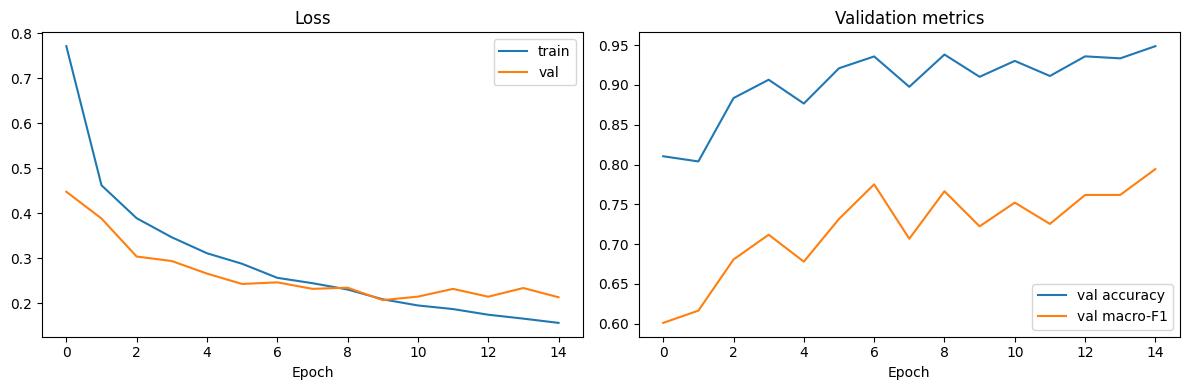

In [9]:
#learning curves
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history["val_acc"], label="val accuracy"); ax[1].plot(history["val_f1"], label="val macro-F1")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

In [10]:
#fresh model, with a learning-rate scheduler
import torch, torch.nn as nn

torch.manual_seed(42)
model = ECGCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3)   # halve the LR if val macro-F1 stalls for 3 epochs

In [11]:
#train for 40 epochs, keep the best checkpoint
EPOCHS = 40
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
best_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc, va_f1 = evaluate(model, val_loader)
    scheduler.step(va_f1)

    for k, v in zip(history, [tr_loss, va_loss, va_acc, va_f1]):
        history[k].append(v)

    saved = ""
    if va_f1 > best_f1:
        best_f1 = va_f1
        torch.save(model.state_dict(), "/kaggle/working/ecg_model.pth")
        saved = "  <- saved"

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:2d} | train loss {tr_loss:.4f} | val loss {va_loss:.4f} "
          f"acc {va_acc:.4f} F1 {va_f1:.4f} | lr {lr:.5f}{saved}")

Epoch  1 | train loss 0.7730 | val loss 0.4596 acc 0.8213 F1 0.6109 | lr 0.00100  <- saved
Epoch  2 | train loss 0.4623 | val loss 0.3794 acc 0.8137 F1 0.6252 | lr 0.00100  <- saved
Epoch  3 | train loss 0.3879 | val loss 0.2953 acc 0.8885 F1 0.6890 | lr 0.00100  <- saved
Epoch  4 | train loss 0.3514 | val loss 0.2904 acc 0.9054 F1 0.7115 | lr 0.00100  <- saved
Epoch  5 | train loss 0.3116 | val loss 0.2689 acc 0.8949 F1 0.6981 | lr 0.00100
Epoch  6 | train loss 0.2918 | val loss 0.2443 acc 0.9177 F1 0.7286 | lr 0.00100  <- saved
Epoch  7 | train loss 0.2586 | val loss 0.2413 acc 0.9298 F1 0.7628 | lr 0.00100  <- saved
Epoch  8 | train loss 0.2434 | val loss 0.2326 acc 0.9132 F1 0.7376 | lr 0.00100
Epoch  9 | train loss 0.2279 | val loss 0.2336 acc 0.9296 F1 0.7548 | lr 0.00100
Epoch 10 | train loss 0.2127 | val loss 0.2162 acc 0.9157 F1 0.7304 | lr 0.00100
Epoch 11 | train loss 0.1938 | val loss 0.2050 acc 0.9175 F1 0.7326 | lr 0.00050
Epoch 12 | train loss 0.1692 | val loss 0.2178 ac

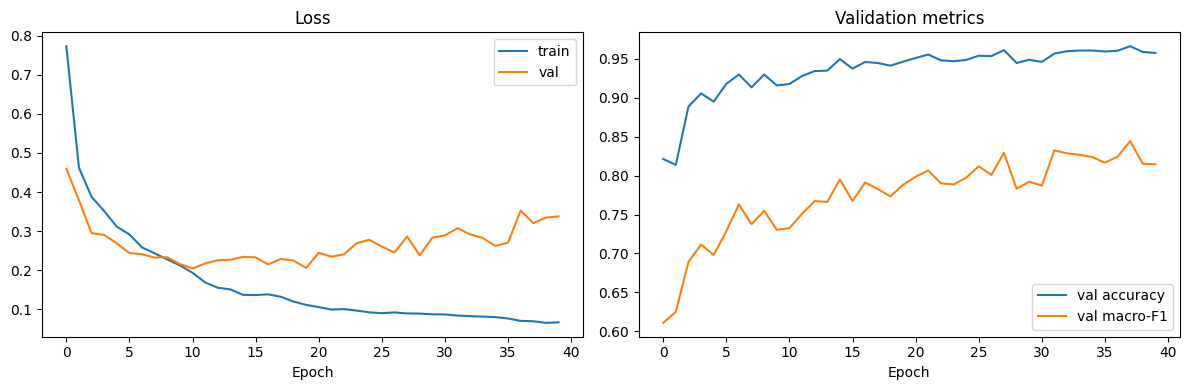

In [12]:
#learning curves
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history["val_acc"], label="val accuracy"); ax[1].plot(history["val_f1"], label="val macro-F1")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

           N      0.994     0.962     0.978     18118
           S      0.532     0.856     0.656       556
           V      0.891     0.951     0.920      1448
           F      0.511     0.895     0.650       162
           Q      0.978     0.988     0.983      1608

    accuracy                          0.960     21892
   macro avg      0.781     0.930     0.837     21892
weighted avg      0.971     0.960     0.964     21892



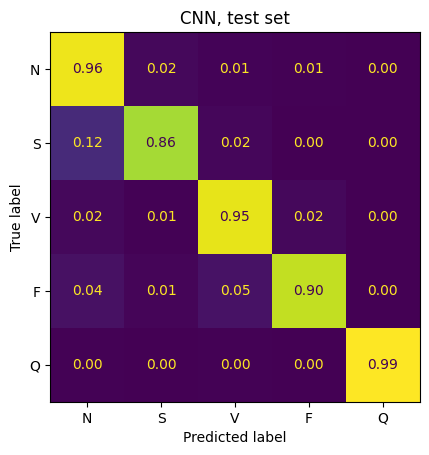

{'accuracy': 0.9602594555088617, 'macro_f1': 0.8374536045897605}


In [13]:
#final evaluation on the TEST set (do this once)
import json
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

model.load_state_dict(torch.load("/kaggle/working/ecg_model.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.append(model(xb.to(device)).argmax(1).cpu())
        all_labels.append(yb)
preds = torch.cat(all_preds).numpy()
labels = torch.cat(all_labels).numpy()

names = ["N", "S", "V", "F", "Q"]
print(classification_report(labels, preds, target_names=names, digits=3))

cm = confusion_matrix(labels, preds, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=names).plot(values_format=".2f", colorbar=False)
plt.title("CNN, test set"); plt.show()

results = {"accuracy": float((preds == labels).mean()),
           "macro_f1": float(f1_score(labels, preds, average="macro"))}
print(results)
with open("/kaggle/working/cnn_results.json", "w") as f:
    json.dump(results, f, indent=2)

In [14]:
# will this file work on a CPU-only server like Render?
import os
cpu_model = ECGCNN()
cpu_model.load_state_dict(torch.load("/kaggle/working/ecg_model.pth", map_location="cpu"))
cpu_model.eval()

sample = torch.from_numpy(X_test[:1]).unsqueeze(1)          # one beat, shape (1, 1, 187)
with torch.no_grad():
    probs = torch.softmax(cpu_model(sample), dim=1)
print("probabilities:", probs.numpy().round(3), "| true label:", y_test[0])
print("file size (KB):", os.path.getsize("/kaggle/working/ecg_model.pth") / 1024)

probabilities: [[1. 0. 0. 0. 0.]] | true label: 0
file size (KB): 424.7236328125


## improving model

In [15]:
#a configurable model (use_bn, channels, etc.)
import copy, json, numpy as np, pandas as pd, torch, torch.nn as nn
from sklearn.metrics import f1_score, precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ECGCNN2(nn.Module):
    def __init__(self, num_classes=5, channels=(16, 32, 64), use_bn=False, dropout=0.3, hidden=64):
        super().__init__()
        layers, in_ch, length = [], 1, 187
        for out_ch in channels:
            layers.append(nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2))
            if use_bn:
                layers.append(nn.BatchNorm1d(out_ch))
            layers += [nn.ReLU(), nn.MaxPool1d(2)]
            in_ch, length = out_ch, length // 2
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch * length, hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [16]:
#helpers and the experiment runner
@torch.no_grad()
def predict(model, loader):
    model.eval()
    P, L = [], []
    for xb, yb in loader:
        P.append(model(xb.to(device)).argmax(1).cpu())
        L.append(yb)
    return torch.cat(P).numpy(), torch.cat(L).numpy()

def run_experiment(name, cfg, epochs=30, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    model = ECGCNN2(**cfg["model"]).to(device)

    counts = np.bincount(y_tr, minlength=5)
    w = (len(y_tr) / (5 * counts)) ** cfg["w_power"]          # w_power 1.0 = balanced, 0.5 = softer
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=cfg.get("wd", 0.0))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best = {"f1": -1.0}
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            if cfg.get("aug"):
                xb = xb + 0.01 * torch.randn_like(xb)                          # small noise
                xb = torch.roll(xb, shifts=int(np.random.randint(-3, 4)), dims=2)  # tiny time shift
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        preds, labels = predict(model, val_loader)
        f1 = f1_score(labels, preds, average="macro")
        scheduler.step(f1)
        if f1 > best["f1"]:
               best = {"f1": f1, "epoch": epoch, "preds": preds, "labels": labels, "state": copy.deepcopy(model.state_dict())}

    p, r, _, _ = precision_recall_fscore_support(best["labels"], best["preds"], labels=range(5), zero_division=0)
    row = {"run": name, "seed": seed, "val_macro_f1": round(best["f1"], 4), "best_epoch": best["epoch"],
           "S_prec": round(p[1], 3), "S_rec": round(r[1], 3),
           "F_prec": round(p[3], 3), "F_rec": round(r[3], 3), "N_rec": round(r[0], 3)}
    return row, best["state"]

In [17]:
#define and run the five experiments (about 10-15 minutes in total)
experiments = {
    "A_baseline":     {"model": {}, "w_power": 1.0},
    "B_sqrt_weights": {"model": {}, "w_power": 0.5},
    "C_bn":           {"model": {"use_bn": True}, "w_power": 0.5},
    "D_bn_aug":       {"model": {"use_bn": True}, "w_power": 0.5, "aug": True},
    "E_wide_bn_aug":  {"model": {"use_bn": True, "channels": (32, 64, 128), "hidden": 128, "dropout": 0.4},
                       "w_power": 0.5, "aug": True, "wd": 1e-4},
}

rows, states = [], {}
for name, cfg in experiments.items():
    row, state = run_experiment(name, cfg, seed=42)
    rows.append(row); states[(name, 42)] = state
    print(row)

pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)

{'run': 'A_baseline', 'seed': 42, 'val_macro_f1': 0.8383, 'best_epoch': 28, 'S_prec': np.float64(0.601), 'S_rec': np.float64(0.923), 'F_prec': np.float64(0.41), 'F_rec': np.float64(0.859), 'N_rec': np.float64(0.964)}
{'run': 'B_sqrt_weights', 'seed': 42, 'val_macro_f1': 0.9126, 'best_epoch': 22, 'S_prec': np.float64(0.852), 'S_rec': np.float64(0.829), 'F_prec': np.float64(0.733), 'F_rec': np.float64(0.859), 'N_rec': np.float64(0.99)}
{'run': 'C_bn', 'seed': 42, 'val_macro_f1': 0.9226, 'best_epoch': 21, 'S_prec': np.float64(0.872), 'S_rec': np.float64(0.856), 'F_prec': np.float64(0.727), 'F_rec': np.float64(0.875), 'N_rec': np.float64(0.993)}
{'run': 'D_bn_aug', 'seed': 42, 'val_macro_f1': 0.8968, 'best_epoch': 14, 'S_prec': np.float64(0.864), 'S_rec': np.float64(0.833), 'F_prec': np.float64(0.614), 'F_rec': np.float64(0.844), 'N_rec': np.float64(0.985)}
{'run': 'E_wide_bn_aug', 'seed': 42, 'val_macro_f1': 0.9071, 'best_epoch': 22, 'S_prec': np.float64(0.847), 'S_rec': np.float64(0.896)

,run,seed,val_macro_f1,best_epoch,S_prec,S_rec,F_prec,F_rec,N_rec
2,C_bn,42,0.9226,21,0.872,0.856,0.727,0.875,0.993
1,B_sqrt_weights,42,0.9126,22,0.852,0.829,0.733,0.859,0.990
4,E_wide_bn_aug,42,0.9071,22,0.847,0.896,0.618,0.859,0.987
3,D_bn_aug,42,0.8968,14,0.864,0.833,0.614,0.844,0.985
0,A_baseline,42,0.8383,28,0.601,0.923,0.410,0.859,0.964


In [18]:
#re-run the top contenders with 2 more seeds, to see what's real and what's noise
finalists = ["B_sqrt_weights","C_bn", "E_wide_bn_aug"]          # <- edit this after reading the above Cell table (pick the best 3)
more = []
for name in ["A_baseline"] + finalists:
    for seed in (1, 2):
        row, state = run_experiment(name, experiments[name], seed=seed)
        more.append(row); states[(name, seed)] = state

allruns = pd.DataFrame(rows + more)
allruns = allruns[allruns["run"].isin(["A_baseline"] + finalists)]
summary = allruns.groupby("run")[["val_macro_f1", "S_prec", "S_rec", "F_prec", "F_rec"]].mean().round(3)
summary["f1_spread"] = allruns.groupby("run")["val_macro_f1"].agg(lambda s: s.max() - s.min()).round(3)
summary

,val_macro_f1,S_prec,S_rec,F_prec,F_rec,f1_spread
run,,,,,,
A_baseline,0.840,0.556,0.922,0.475,0.859,0.015
B_sqrt_weights,0.909,0.825,0.821,0.760,0.828,0.009
C_bn,0.925,0.864,0.866,0.771,0.849,0.006
E_wide_bn_aug,0.904,0.833,0.877,0.649,0.849,0.016


val macro-F1 per seed: {42: 0.9226, 1: 0.9285, 2: 0.9248}
chosen seed: 1
              precision    recall  f1-score   support

           N      0.992     0.992     0.992     18118
           S      0.839     0.817     0.828       556
           V      0.956     0.951     0.953      1448
           F      0.772     0.858     0.813       162
           Q      0.988     0.989     0.989      1608

    accuracy                          0.984     21892
   macro avg      0.909     0.921     0.915     21892
weighted avg      0.984     0.984     0.984     21892



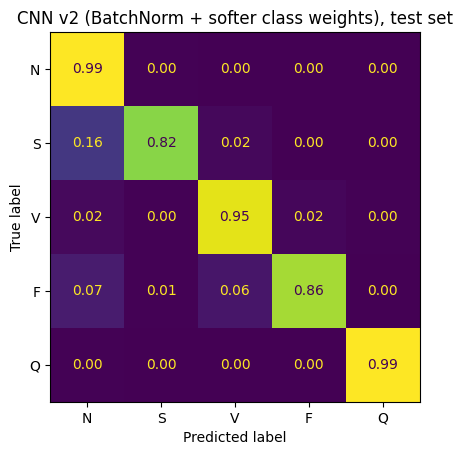

{'accuracy': 0.9837383519093733, 'macro_f1': 0.9149427871174988}


In [19]:
#picking the best c seed and testing it once
import json, os
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cfg = experiments["C_bn"]["model"]

# choose the seed by VALIDATION macro-F1 (never by test)
scores = {}
for seed in (42, 1, 2):
    m = ECGCNN2(**cfg).to(device); m.load_state_dict(states[("C_bn", seed)])
    p, l = predict(m, val_loader)
    scores[seed] = f1_score(l, p, average="macro")
print("val macro-F1 per seed:", {k: round(v, 4) for k, v in scores.items()})
best_seed = max(scores, key=scores.get)
print("chosen seed:", best_seed)

model = ECGCNN2(**cfg).to(device)
model.load_state_dict(states[("C_bn", best_seed)])
torch.save(model.state_dict(), "/kaggle/working/ecg_model_v2.pth")

# TEST evaluation: do this once, then don't tune anything else
preds, labels = predict(model, test_loader)
names = ["N", "S", "V", "F", "Q"]
print(classification_report(labels, preds, target_names=names, digits=3))
cm = confusion_matrix(labels, preds, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=names).plot(values_format=".2f", colorbar=False)
plt.title("CNN v2 (BatchNorm + softer class weights), test set"); plt.show()

results = {"accuracy": float((preds == labels).mean()),
           "macro_f1": float(f1_score(labels, preds, average="macro"))}
print(results)
json.dump(results, open("/kaggle/working/cnn_v2_results.json", "w"), indent=2)

In [20]:
# CPU check
cpu = ECGCNN2(**cfg)
cpu.load_state_dict(torch.load("/kaggle/working/ecg_model_v2.pth", map_location="cpu"))
cpu.eval()
x = torch.from_numpy(X_test[:1]).unsqueeze(1)
with torch.no_grad():
    print(torch.softmax(cpu(x), dim=1).numpy().round(3), "| true:", y_test[0],
          "| KB:", os.path.getsize("/kaggle/working/ecg_model_v2.pth") / 1024)

[[1. 0. 0. 0. 0.]] | true: 0 | KB: 430.7998046875
